# Setup

In [ ]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import time
import pickle
from tqdm import tqdm
import sys
from pathlib import Path
from scipy.optimize import curve_fit

✅ BMC lib found. Running in control mode.


In [2]:
# Constants
lam = 1551 # [nm]
light_lam = 1551 # [nm]

In [ ]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

# Setup
path = phobos.archive.new('bench_alignment', verbose=True)


Injected segments: [138, 137, 136, 135]
Archive created at /mnt/disk1/archive/2026-07-17_602833e/1_rms_lam1551
Archive created at /mnt/disk1/archive/2026-07-17_602833e/2_test_reboot


In [4]:
phobos.Config().set('dm.stabilization_time', 0.002, autosave=False)
phobos.Config().set('photonic_chip.stabilization_time', 0.003, autosave=False)

In [5]:
phobos.Config().get('photonic_chip.stabilization_time')

0.003

# Check cropping

✅ Cred3 reset to configuration defaults.


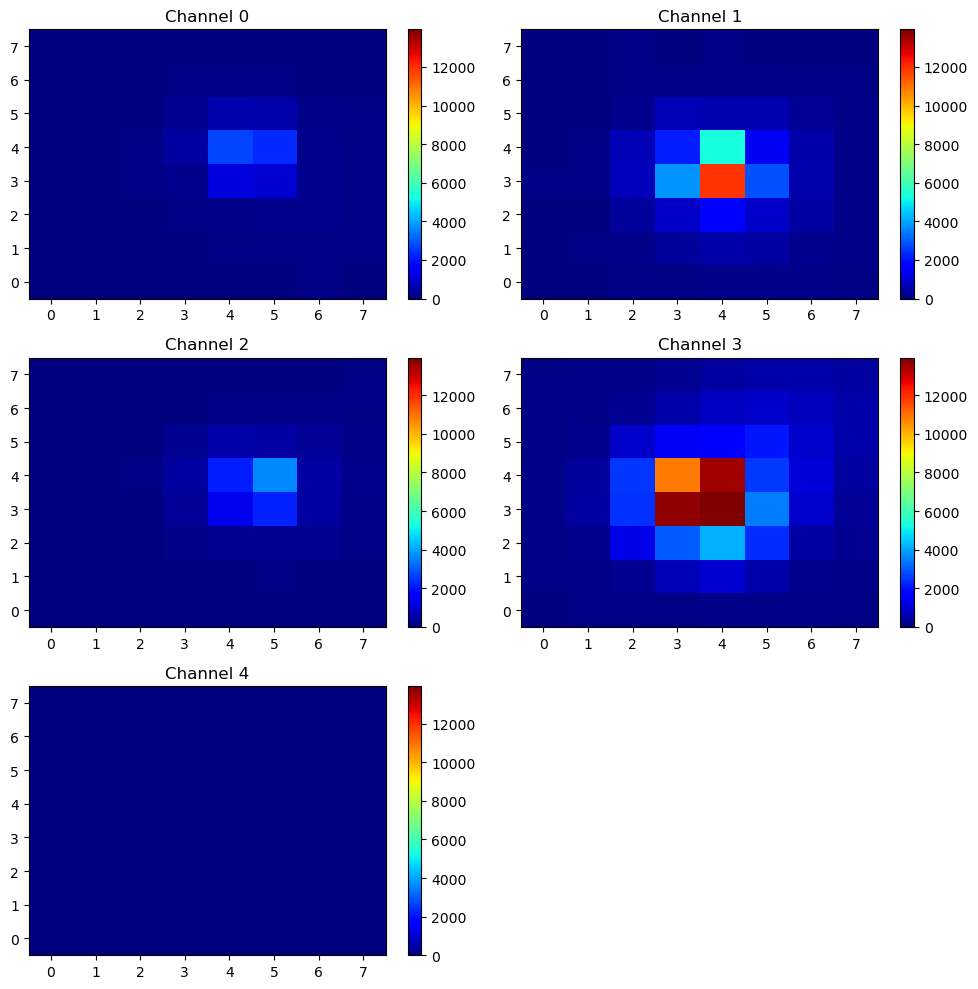

In [5]:
# check cropping
phobos.Config().reload()
cam.reset()
cam.check_cropping(crop_mode='centers')

# Calibration injection

In [6]:
# Injection calibration
inj = phobos.Injection()


In [ ]:
# inj.zero()
# maps = inj.get_injection_maps(verbose=True)
# inj.zero()

# fig = plt.figure(figsize=(10,10))
# for i in range(4):
#     image = maps[0][i]
#     tip_range = tilt_ramp = maps[1]
#     tilt_step = np.diff(tilt_ramp)[0]
#     tip_step = np.diff(tip_range)[0]
#     plt.subplot(2,2,i+1)
#     plt.imshow(image, origin='lower', cmap='jet',
#             extent=[tilt_ramp.min()-tilt_step/2, tilt_ramp.max()+tilt_step/2,
#                     tip_range.min()-tip_step/2, tip_range.max()+tip_step/2],
#             vmin=maps[0].min(),
#             vmax=maps[0].max())
#     plt.colorbar()
#     plt.xlabel('Tilt (mrad)')
#     plt.ylabel('Tip (mrad)')
# plt.tight_layout()

Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:17<00:51, 17.28s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:34<00:35, 17.50s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:56<00:19, 19.23s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:16<00:00, 19.03s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection spread of seg=138: (tip, tilt) = (0.69033,0.74896) mrad
Injection spread of seg=137: (tip, tilt) = (0.72071,0.75982) mrad
Injection spread of seg=136: (tip, tilt) = (0.71484,0.74510) mrad
Injection spread of seg=135: (tip, tilt) = (0.73390,0.77563) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.36901,-0.13733) mrad; flux = 856.5
Injection max of seg=137: (tip, tilt) = (-0.07680,-0.24236) mrad; flux = 832.5
Injection max of seg=136: (tip, tilt) = (0.28760,-0.32723) mrad; flux = 706.1
Injection max of seg=135: (tip, tilt) = (0.44582,-0.32742) mrad; flux = 624.4
✅ Injection calibration saved to config (injection.max)


Successfully saved in FITS
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


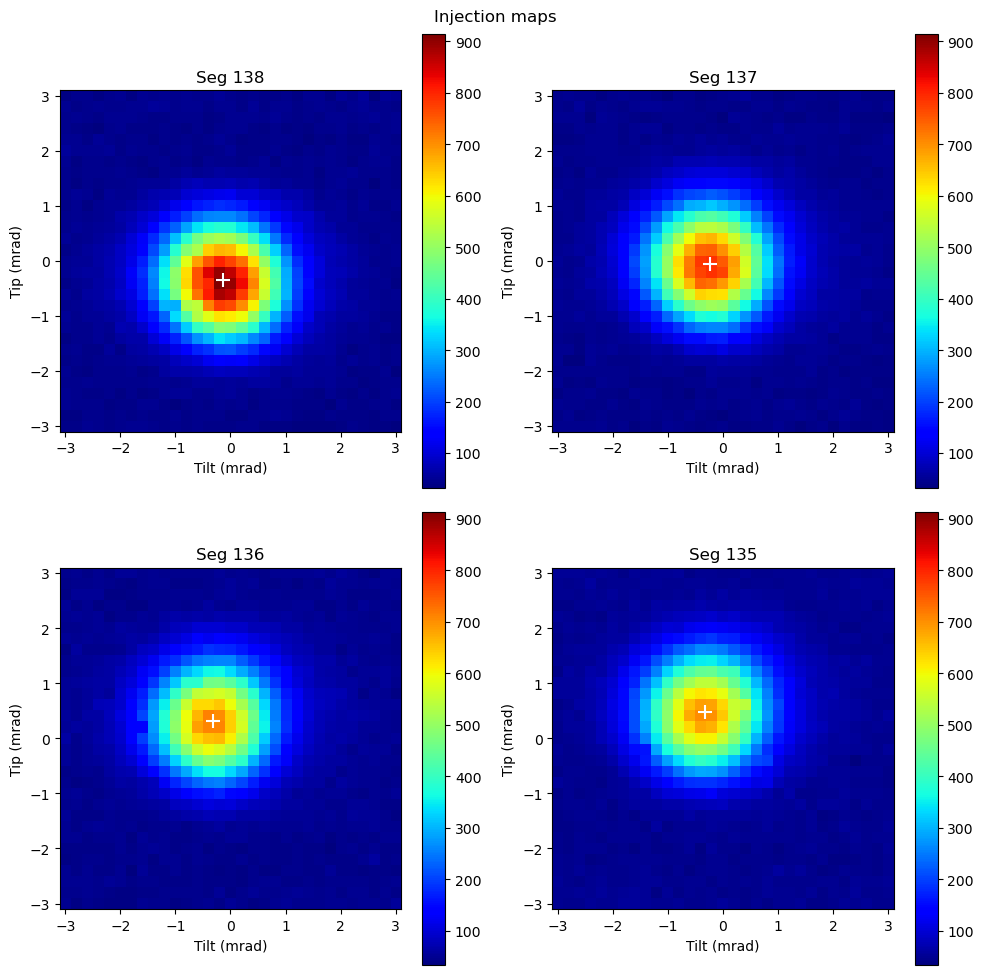

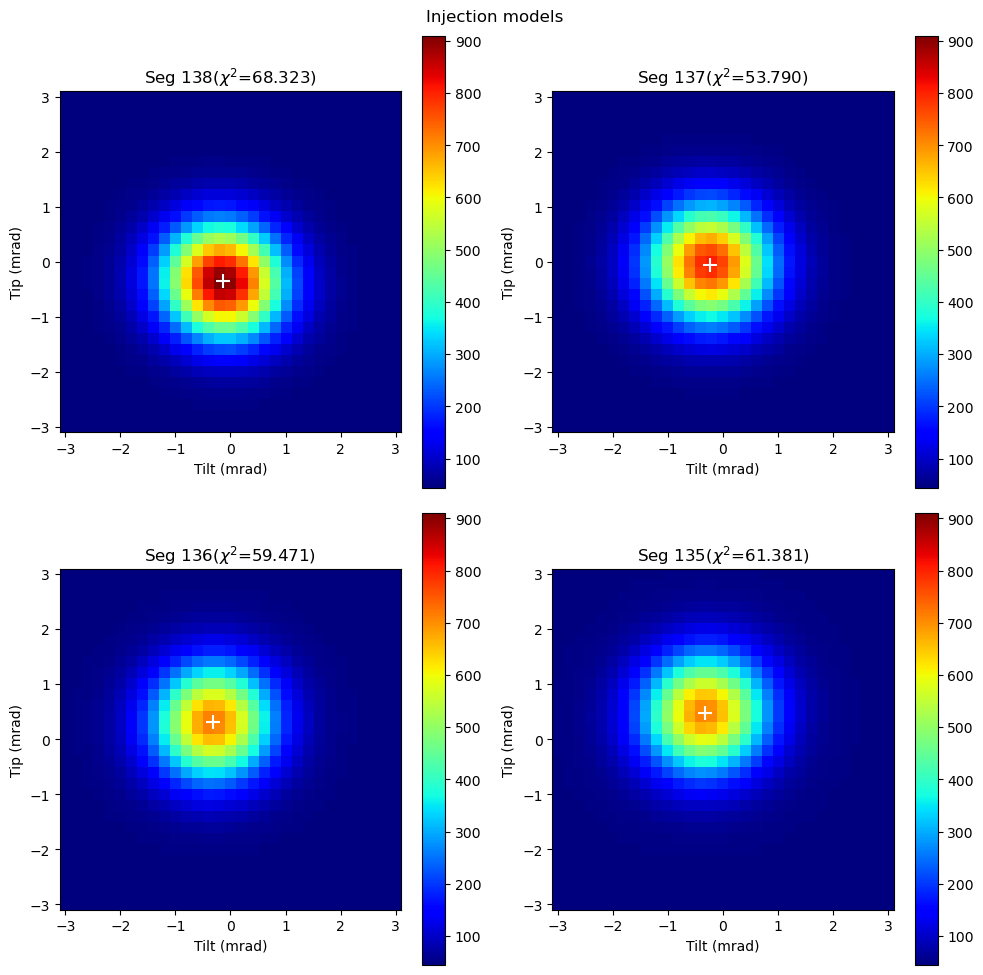

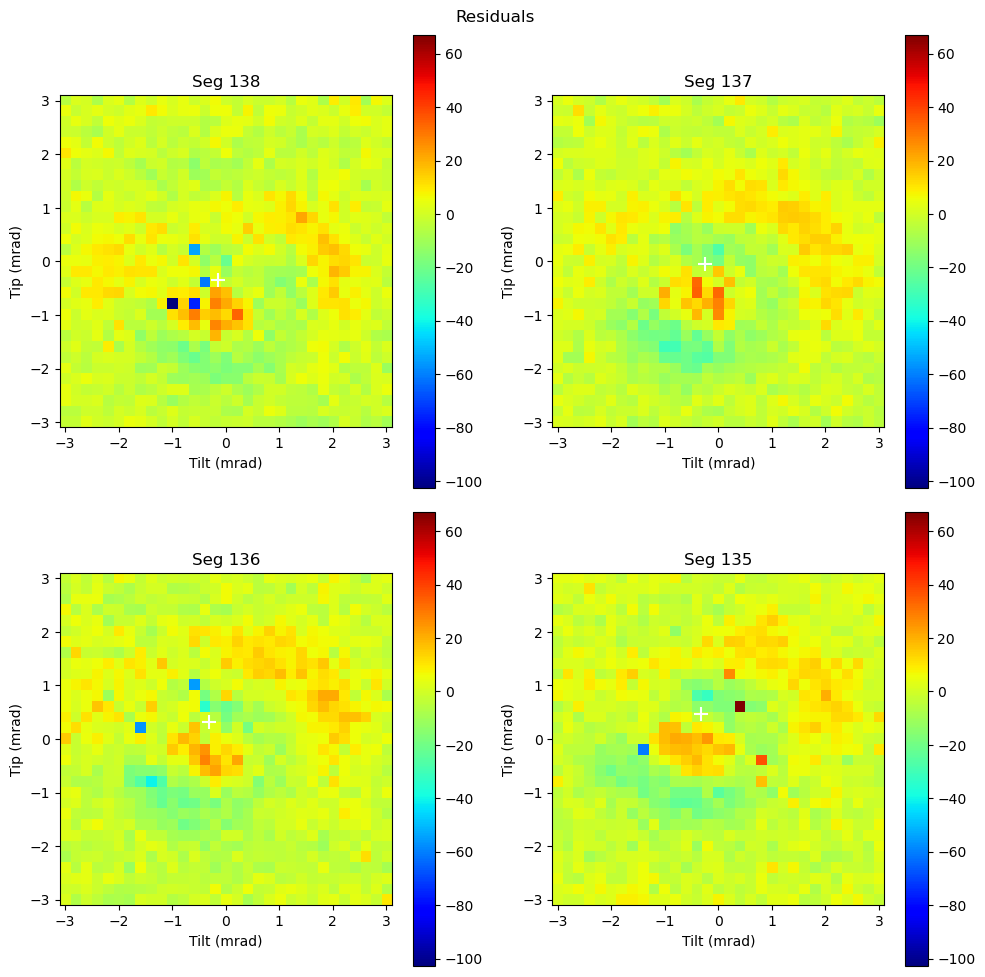

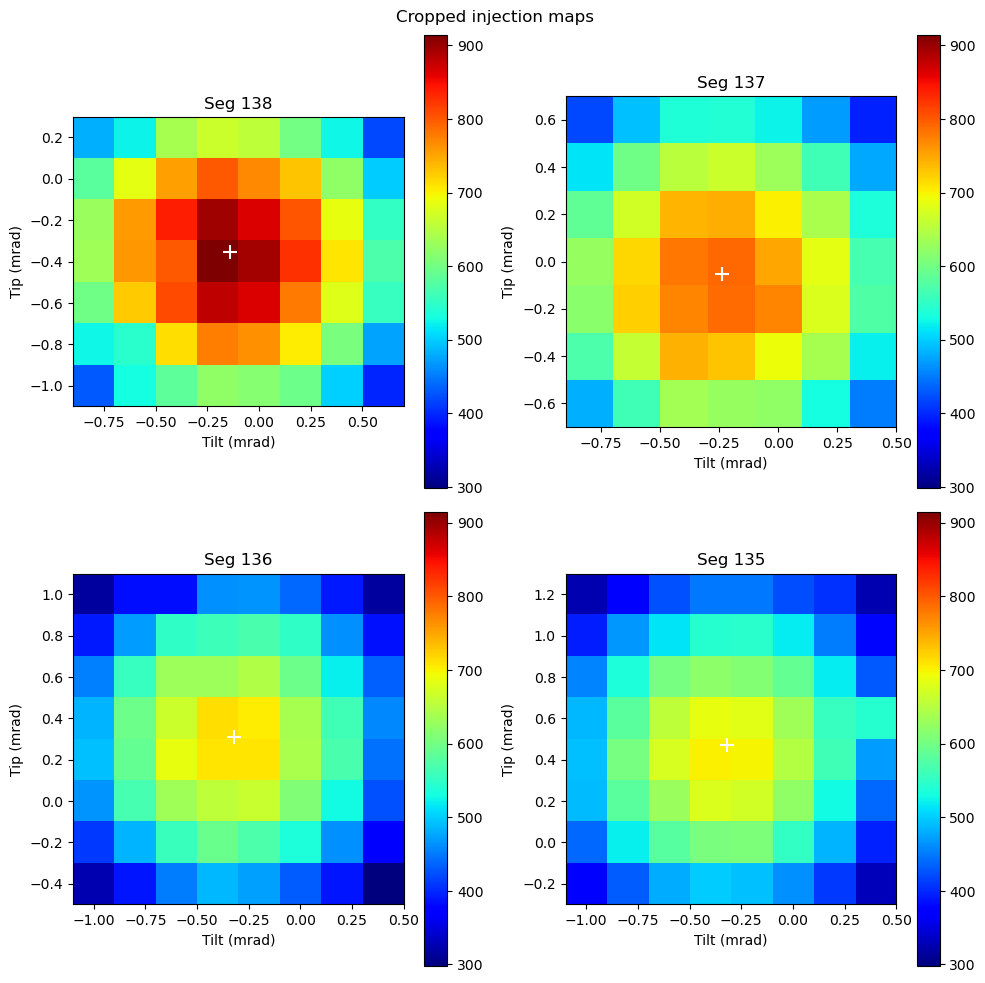

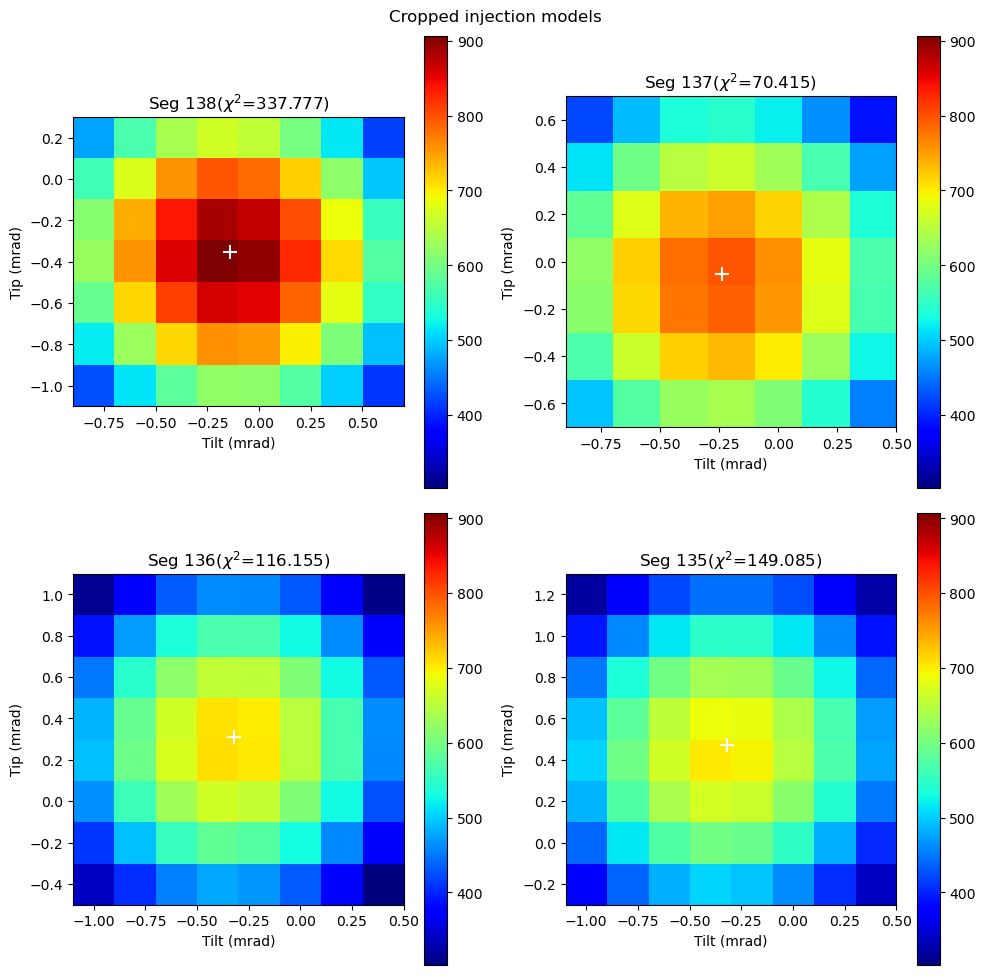

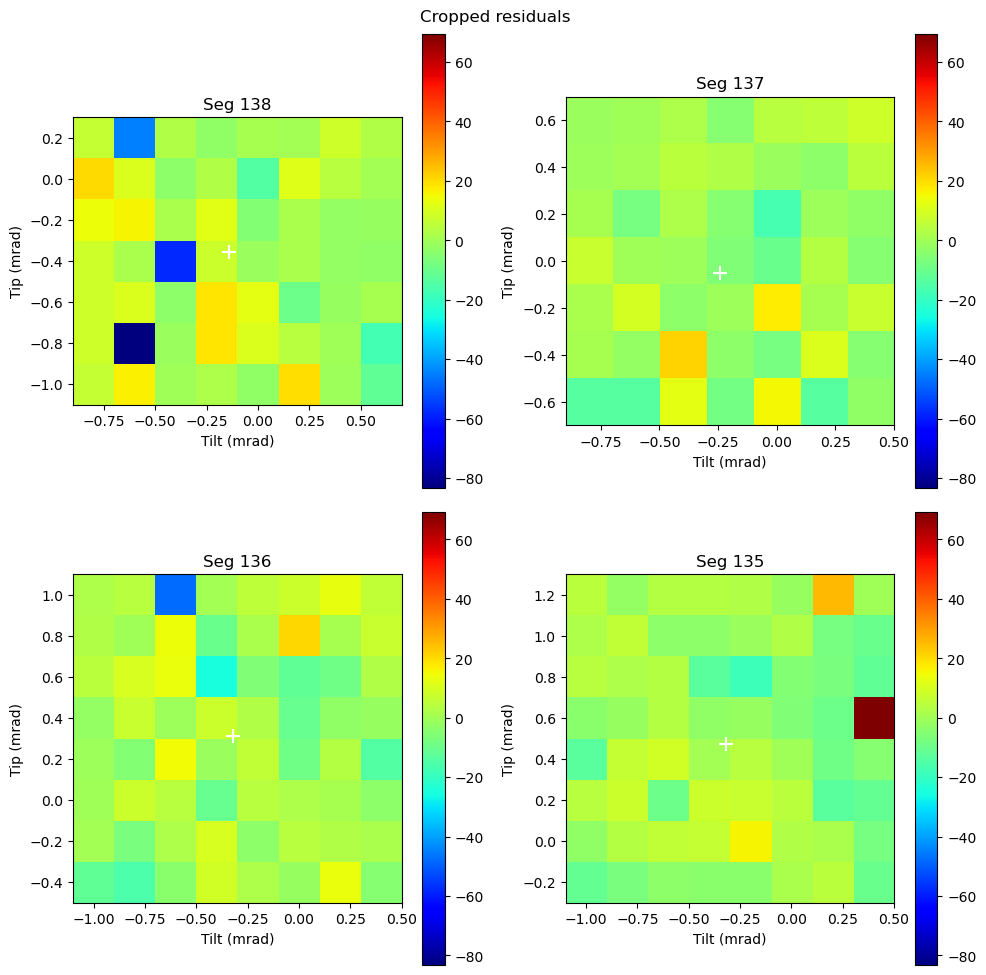

In [7]:
# Injection calibration
avg_frame = 1
avg_frames_bal = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path, 
                        avg_frames=avg_frame, avg_frames_bal=avg_frames_bal,
                        tilt_tol = 0.5e-3, no_balancing=True)

inj.zero()

# Mono-beam scan

In [ ]:
def scan_monobeam(inj_mode, n_ch, n_roi, piston_range):
    all_beams_flux = []
    for beam in range(n_ch):
        inj.off()
        inj_mode(beam)

        ref_tip = dm[inj_seg[beam]].get_tip()
        ref_tilt = dm[inj_seg[beam]].get_tilt()

        outs = np.empty((len(piston_range), n_roi))
        for p, opd in enumerate(piston_range):
            dm[inj_seg[beam]].set_ptt(opd, ref_tip, ref_tilt)
            outs[p] = cam.get_outputs(flux_mode='mean', stack=avg_frames, crop_mode='centers')[:n_roi]
        all_beams_flux.append(outs)
    all_beams_flux = np.array(all_beams_flux)

    return all_beams_flux

In [ ]:
def sine_wave(x, amplitude, frequency, phase):
    return amplitude * np.sin(2 * np.pi * frequency * x + phase)

def sine_with_ramp(x, amplitude, frequency, phase, ramp, offset):
    return amplitude * np.sin(2 * np.pi * frequency * x + phase) + ramp * x + offset

In [ ]:
n_roi = 4
avg_frames = 10
piston_range = np.linspace(-2500, 200, 201)  # [nm]
n_ch = len(inj_seg)
filename = 'crosstalk_dm_scan_max'

balanced_all_beams = scan_monobeam(inj.set_balanced, n_ch, n_roi, piston_range)
np.savez(path / filename, flux=balanced_all_beams, piston_range=piston_range, lam=lam)

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for beam in range(n_ch):
    for o in range(n_roi):
        axs[beam].plot(piston_range / (lam/2), balanced_all_beams[beam, :, o], color=colors[o], linestyle='-', label=f'Output {o}')
        axs[beam].plot(piston_range / (lam/2), balanced_all_beams[beam].mean(1), color='k', linestyle='-', label=f'Mean')
    axs[beam].set_title(f'Segment {inj_seg[beam]}')
    axs[beam].set_xlabel(r'Piston [$\lambda/2$]')
    axs[beam].set_ylabel('Output Flux')
    axs[beam].legend()
    axs[beam].grid()

fig.tight_layout()
fig.savefig(path / filename, format='png', dpi=150)

total_flux = balanced_all_beams.sum(2)


res = []
fig, axs = plt.subplots(1, 1, figsize=(5, 5))

for o in range(n_ch):
    y =  balanced_all_beams[beam].sum(1)
    axs.plot(piston_range / (lam/2), y, 
             color=colors[o], linestyle='o', label=f'Segment {inj_seg[o]}')
    p0 = [1., 1/(lam/2), 0., 0., y.mean()]
    boundaries = ((0., 1/(lam/2)*0.9, -np.pi, -np.inf, y.min()), (y.max(), 1/(lam/2)*1.1, np.pi, np.inf, y.max()))
    popt, _ = curve_fit(sine_with_ramp, piston_range, y, p0=p0, bounds=boundaries)
    res.append(popt[0])
    axs.plot(piston_range / (lam/2), sine_with_ramp(piston_range, *popt), 
             color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')    
axs.set_title('Total Flux')
axs.set_xlabel('Piston [$\lambda/2$]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
filename2 = filename + '_totalflux.png'
fig.savefig(path / filename2, format='png', dpi=150)

inj.set_balanced()
res = np.array(res)

# Pair scans

In [ ]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
nb_lam = 3.
crop_mode = 'rectangles_integrated'
shapes = cam.get_outputs(flux_mode='mean', crop_mode=crop_mode)
n_roi = shapes.shape[0] - 1

res_pair_scan = {}

res_pair = []
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, pair in enumerate(pairs):
    inj.off(verbose=False)
    inj.set_balanced(np.array(pair))

    ref_tip = (dm[inj_seg[pair[0]]].get_tip(), dm[inj_seg[pair[1]]].get_tip())
    ref_tilt = (dm[inj_seg[pair[0]]].get_tilt(), dm[inj_seg[pair[1]]].get_tilt())

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    start = ref_cart - nb_lam * lam/2./2.
    piston_range = np.linspace(start, start + nb_lam * lam/2., 100, endpoint=False)  # [nm]
    opd_range = (piston_range - ref_cart) * 2


    # Scan on first input
    outs = np.empty((len(piston_range), n_roi))
    for p, piston in enumerate(piston_range):
        dm[inj_seg[pair[0]]].set_ptt(piston, ref_tip[0], ref_tilt[0])
        if p == 0:
            time.sleep(0.1)
        outs[p] = cam.get_outputs(flux_mode='mean', crop_mode=crop_mode)[:n_roi]

    dm[inj_seg[pair[0]]].set_ptt(ref_cart, ref_tip[0], ref_tilt[0])
    time.sleep(0.1)

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[0], pair[1])] = data

    for o in range(n_roi):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')
    axs[i].plot(opd_range / lam, outs.mean(1), color='k', linestyle='-', alpha=0.6, label='Mean')

    p0 = [1., 1/lam, 0., 0., outs.mean()]
    boundaries = ((0., 1/lam*0.9, -np.pi, -np.inf, outs.min()), (outs.max(), 1/lam*1.1, np.pi, np.inf, outs.max()))
    popt, _ = curve_fit(sine_with_ramp, opd_range, outs.mean(1), p0=p0, bounds=boundaries)
    res_pair.append(popt[0])
    axs[i].plot(opd_range / lam, sine_with_ramp(opd_range, *popt), color='k', linestyle='--', alpha=0.6)

    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()

fig.tight_layout()
filename = 'pair_dm_scan_start%.0f_nb_lam%s.png'%(start, nb_lam)
fig.savefig(path / filename, dpi=150, format='png')

filename = 'pair_dm_scan_data_start%.0f_nb_lam%s.pkl'%(start, nb_lam)
with open(path / filename, 'wb') as f:
    pickle.dump(res_pair_scan, f)

inj.set_balanced()
res_pair = np.array(res_pair)

# The end

In [135]:
print('Path is', path)

inj.zero()

Path is /mnt/disk1/archive/2026-06-11_b9ed59a/3_dispersed
Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
